# Direct LLM Baseline (No Agent)

Naive baseline for comparison against `visualization_orchestrator_demo.ipynb`'s agent pipeline. This notebook deliberately skips **everything** `visualization_orchestrator/specialists/isovalue_adapter.py` does to avoid hallucination (see that module's docstring, `isovalue_llm_findings_and_next_steps.md`, and `isovalue_skull_misperception_problem.md`):

- no fixed-window blind staging
- no goal-blind observation / goal-aware selection split
- no structured success-criteria checking
- no verifier
- no reference-image grounding

It just shows the model the current render **and** the goal **in the same call**, and asks it to pick an isovalue directly -- the exact anti-pattern the agent pipeline was built to avoid. Use this to demonstrate, empirically, why the agent pipeline exists (or to show it's overkill, if this baseline turns out fine).

## Setup

Scene initialized. Isovalue=40, dims=(128, 256, 256).


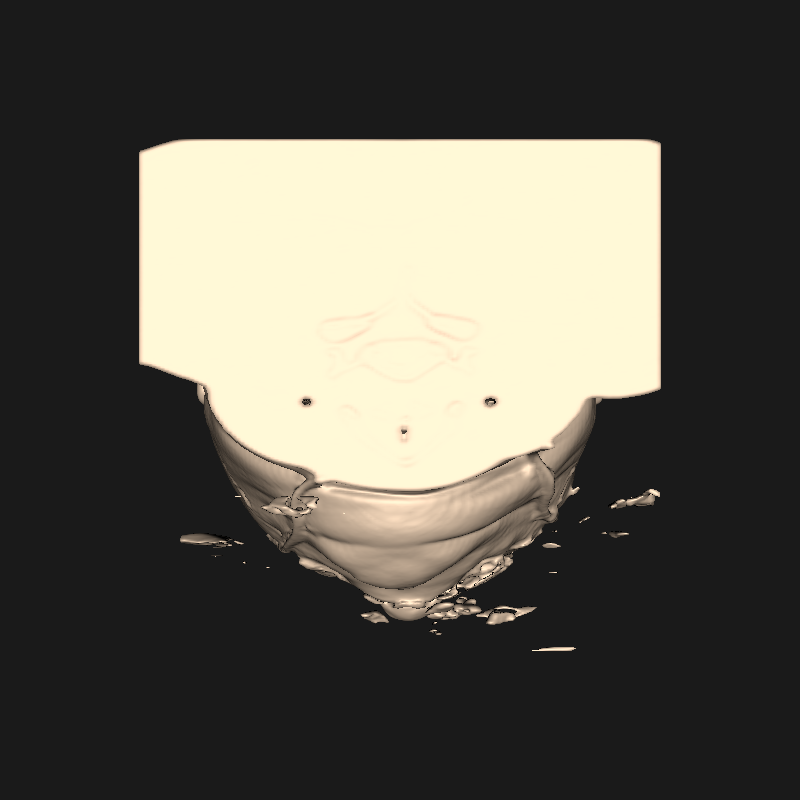

In [5]:
# Requires OPENAI_API_KEY set (see ../.env.example) -- every call in this notebook is a
# real LLM call, and a working VTK install for rendering.
import sys, os
sys.path.insert(0, os.path.abspath('..'))

from IPython.display import Image, display
import json

from camera_reasoning.session import CameraReasoningSession
from camera_reasoning.chatgpt_client import ask_chatgpt
from visualization_orchestrator.json_utils import extract_json_object

DATASET_PATH = "../data/vis_male_128x256x256_uint8.raw"
DIMENSIONS = (128, 256, 256)
# This dataset's real per-axis voxel spacing -- without it, the default isotropic (1,1,1)
# squeezes the 128-slice axis to half the physical width of the 256-slice axes (128*1.0 vs
# 256*1.0), since the real spacing is what's meant to compensate for the axis having half
# as many slices (see volume_scene.py's load_raw_volume, and the same value used in
# visualization_orchestrator_demo.ipynb's vis_male setup cell).
SPACING = (2, 1, 1)
STARTING_ISOVALUE = 40

session = CameraReasoningSession(
    raw_path=DATASET_PATH,
    dimensions=DIMENSIONS,
    spacing=SPACING,
    isovalue=STARTING_ISOVALUE,
    output_dir="../output/direct_llm_baseline",
)
session.initialize()
baseline_image = session.render_and_save()
display(Image(filename=baseline_image))

## The naive one-shot prompt

Deliberately shows the goal and the image together in one call -- see the module docstring in `visualization_orchestrator/specialists/isovalue_adapter.py` for the confirmed hallucination this specific pattern causes (asked to "show the skull", the model described smooth soft tissue as "a complete skull... clear anatomical detail", with high confidence).

Extended beyond the original isovalue-only baseline: the model now also proposes the camera position in the *same* call, as raw continuous deltas (`azimuth_delta`, `elevation_delta`, `zoom_delta`) applied directly via `session.apply_camera_delta()`. This deliberately skips `camera_reasoning`'s named action vocabulary (`AZIMUTH_LEFT_COARSE`, etc.), blind staging, and candidate-action renders -- it's the same anti-pattern as the isovalue baseline, just extended to cover camera too, so we can see whether the model can find a decent isovalue *and* viewpoint this way, and whether it converges over repeated calls.

In [6]:
DIRECT_PROMPT_TEMPLATE = """
You are controlling a volume-rendering isosurface of a CT scan by choosing a single
isovalue (a threshold from 0 to 255) AND the camera position.

Goal: {goal}

Look at the provided image, which shows the CURRENT render at isovalue={current_isovalue},
from the CURRENT camera position. Decide whether this already achieves the goal, and if
not, propose a new isovalue and a camera adjustment that would achieve it better.

Camera adjustments are RELATIVE deltas applied to the CURRENT camera (not absolute
positions):
- azimuth_delta: degrees to orbit the camera around the object, left(-)/right(+)
- elevation_delta: degrees to orbit the camera around the object, down(-)/up(+)
- zoom_delta: multiplicative dolly factor -- greater than 1.0 moves closer, less than 1.0
  moves farther away, 1.0 means no change

Respond with STRICT JSON ONLY, no prose outside the JSON:
{{
  "current_satisfies_goal": true or false,
  "isovalue": <number from 0 to 255 -- your best single choice; if the current one is
    already good, repeat it>,
  "azimuth_delta": <degrees, e.g. -90 to 90; 0 if no change needed>,
  "elevation_delta": <degrees, e.g. -90 to 90; 0 if no change needed>,
  "zoom_delta": <multiplicative factor, e.g. 0.5 to 2.0; 1.0 if no change needed>,
  "reasoning": "<why you picked these values, referring to what you actually see in the
    image>",
  "confidence": <number from 0.0 to 1.0>
}}
"""


def ask_direct_step(session, goal, model=None):
    """One-shot, goal-aware, image-aware pick of isovalue AND camera deltas in a single
    call -- no named action vocabulary, no blind staging, no candidate renders. This is
    the anti-pattern the agent pipeline avoids, extended from isovalue-only to also cover
    camera positioning."""
    image_path = session.render_and_save()
    prompt = DIRECT_PROMPT_TEMPLATE.format(goal=goal, current_isovalue=session.isovalue)
    response_text = ask_chatgpt(prompt=prompt, screenshot_path=image_path, model=model)
    parsed = extract_json_object(response_text)
    return {
        "image_path": image_path,
        "parsed": parsed,
        "raw_response": response_text,
    }


def apply_direct_step(session, parsed):
    """Apply a parsed ask_direct_step() result to the session: new isovalue plus a raw
    camera delta, both in place -- mirrors what apply_action() does at the vtkCamera
    level, but driven by continuous LLM-proposed numbers instead of a discrete action
    name."""
    if not parsed:
        return
    if "isovalue" in parsed:
        session.set_isovalue(float(parsed["isovalue"]))
    session.apply_camera_delta(
        azimuth=float(parsed.get("azimuth_delta", 0.0) or 0.0),
        elevation=float(parsed.get("elevation_delta", 0.0) or 0.0),
        zoom=float(parsed.get("zoom_delta", 1.0) or 1.0),
    )

## Run it -- iterative, plain, no action vocabulary

Each round is still a single plain call (image + goal together, no blind staging, no
candidate renders) -- but isovalue and camera changes now carry forward round to round
instead of resetting, so the loop lets the model iteratively steer both toward the goal.
Stops early if the model reports `current_satisfies_goal`.

Camera hard-reset to fit scene.
iteration 0: satisfies_goal=False
  isovalue=80  azimuth_delta=90  elevation_delta=0  zoom_delta=1.0  confidence=0.85
  reasoning: The current image shows a skull from what appears to be a superior-oblique view looking down at the cranial vault, with suture lines visible. For a lateral view with the superior aspect at the top, I need to rotate 90 degrees around the skull to view it from the side. The isovalue of 40 appears too low, showing excessive soft tissue detail and some artifacts at the base. Increasing to 80 should better isolate bone tissue for a cleaner skull visualization. The elevation appears roughly correct (showing the skull upright), so no elevation change is needed.



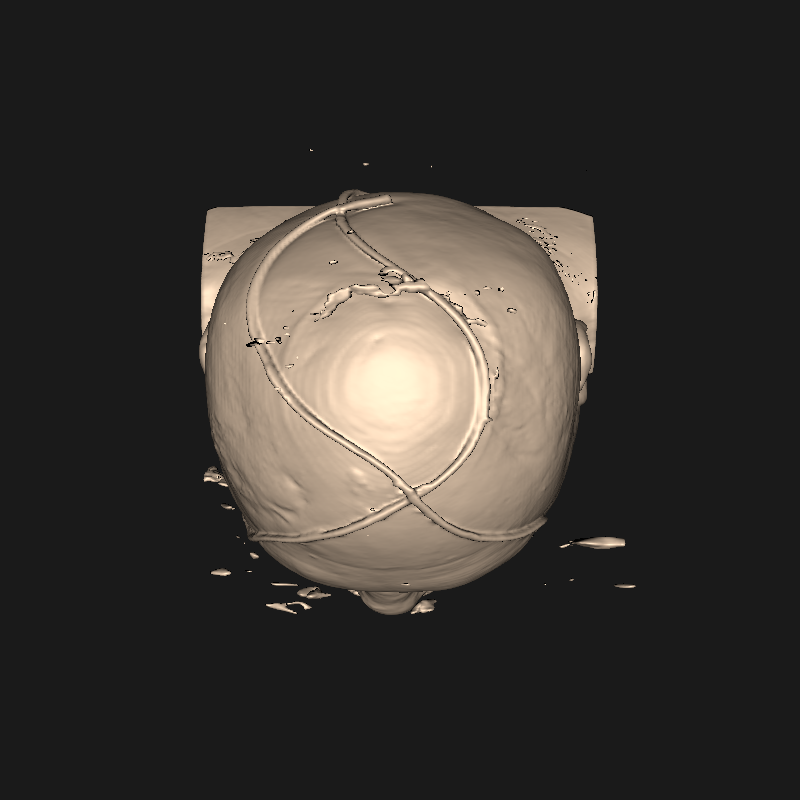

iteration 1: satisfies_goal=False
  isovalue=80.0  azimuth_delta=90  elevation_delta=0  zoom_delta=1.0  confidence=0.85
  reasoning: The current image shows a skull with good bone detail at isovalue 80.0, but the view is incorrect. The current view appears to be looking at the skull from an oblique anterolateral angle, showing both the cranium and the cervical spine/jaw from below. For a proper lateral view with the superior aspect at the top, I need to rotate the camera approximately 90 degrees around the skull (azimuth adjustment) to get a true side view. The isovalue of 80.0 is appropriate as it clearly shows the skull structure without excessive noise or missing bone detail. No elevation change is needed as the superior aspect already appears to be oriented upward.



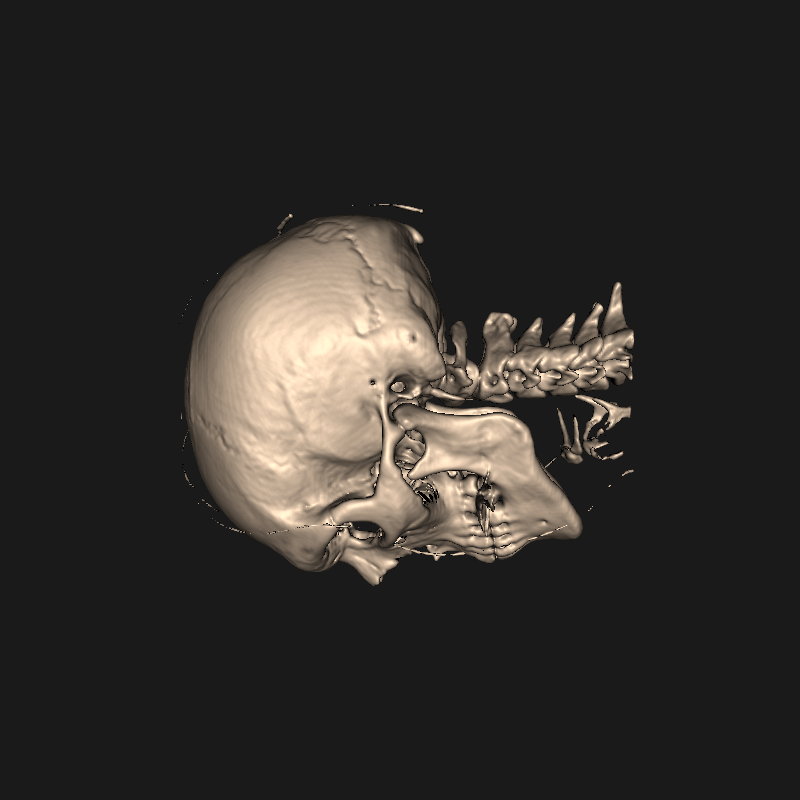

iteration 2: satisfies_goal=False
  isovalue=80.0  azimuth_delta=90  elevation_delta=0  zoom_delta=1.0  confidence=0.85
  reasoning: The current view shows the skull from an inferior/bottom-up perspective, looking up at the base of the skull and mandible. I can see the jaw, vertebrae, and inferior structures prominently. For a lateral view with the superior aspect at the top, I need to rotate the camera horizontally around the skull by approximately 90 degrees to get a side profile view. The isovalue of 80.0 appears appropriate as it's showing good bone detail. No elevation change is needed since we want to maintain a horizontal view plane for the lateral perspective, and zoom appears adequate.



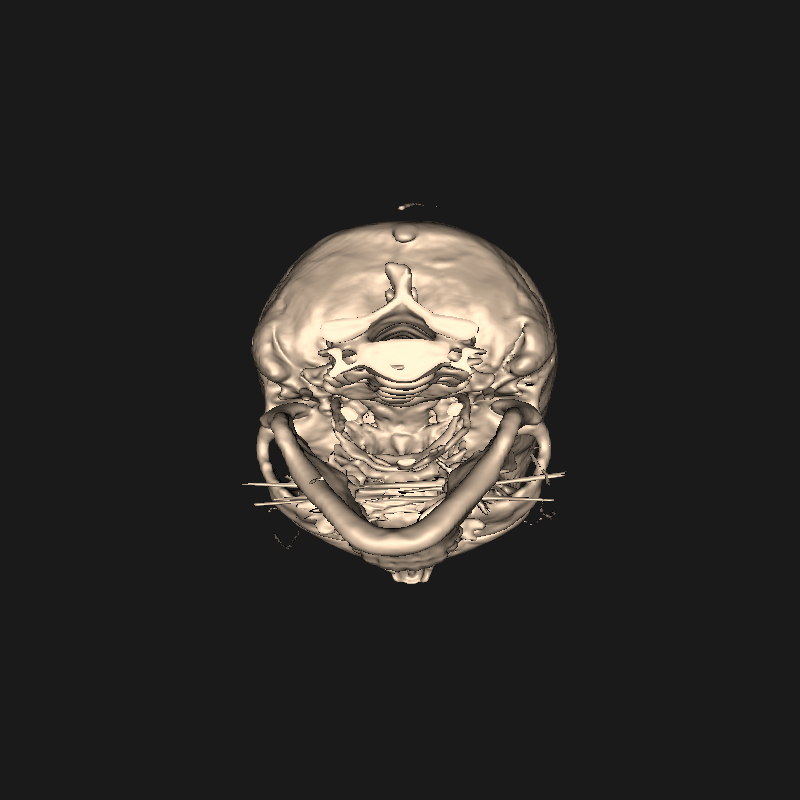

iteration 3: satisfies_goal=False
  isovalue=80.0  azimuth_delta=-90  elevation_delta=0  zoom_delta=1.0  confidence=0.85
  reasoning: The current image shows the skull from an oblique anterolateral view with the spine/cervical vertebrae visible extending to the left. I can see the cranium, mandible, and cervical spine. To achieve a true lateral view with the superior aspect (top of skull) at the top, I need to rotate the camera approximately 90 degrees to the left (negative azimuth) to view the skull from the side. The current vertical orientation appears acceptable with the superior aspect already roughly at the top, so no elevation change is needed. The isovalue of 80 is showing good bone detail, so I'll keep it the same.



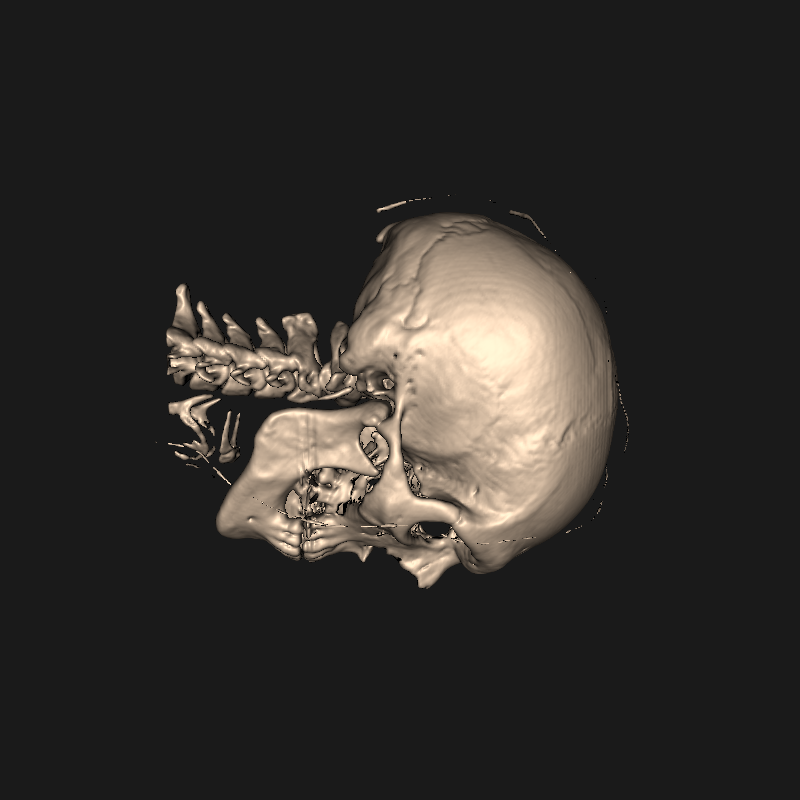

iteration 4: satisfies_goal=False
  isovalue=80.0  azimuth_delta=90  elevation_delta=0  zoom_delta=1.0  confidence=0.85
  reasoning: The current view shows the skull from an inferior (bottom-up) perspective, looking up at the base of the skull and mandible. I can see the mandible, cervical spine, and the inferior aspects of the skull prominently. To achieve a lateral (side) view with the superior aspect (top of head) at the top, I need to rotate the camera 90 degrees around the skull. The isovalue of 80.0 appears appropriate as it clearly shows bone structure. I'm applying a 90-degree azimuth rotation to move to a side view, keeping elevation unchanged since rotating horizontally should give us the proper lateral perspective.



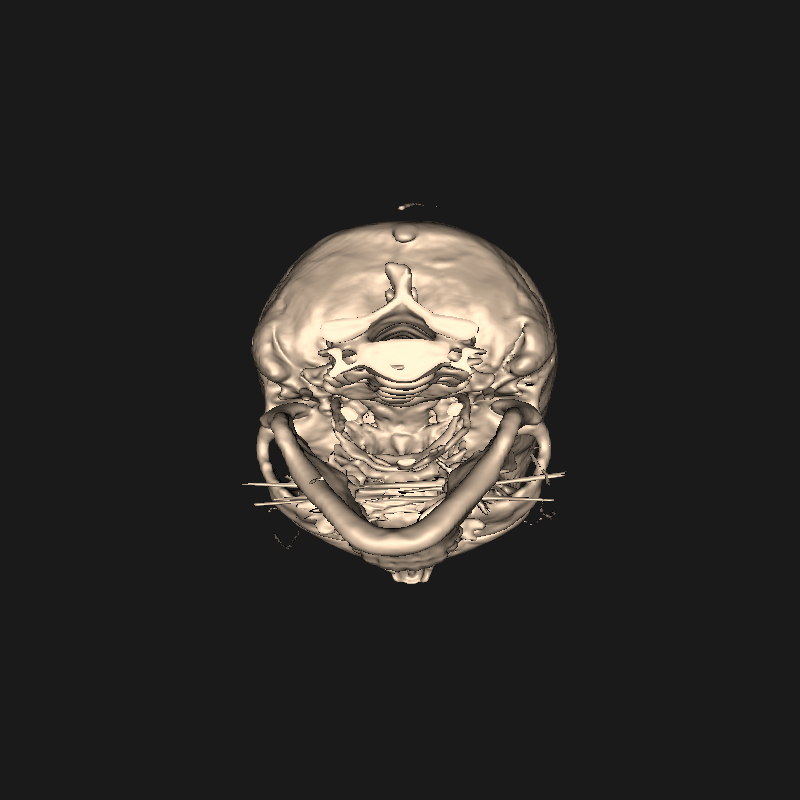

iteration 5: satisfies_goal=False
  isovalue=80.0  azimuth_delta=-90  elevation_delta=0  zoom_delta=1.0  confidence=0.9
  reasoning: The current view shows the skull from an oblique anterolateral angle, with the jaw and cervical spine visible extending to the left. While the superior aspect (top of cranium) is correctly positioned at the top of the image, this is not a true lateral view. A lateral view should show the skull from the side with minimal anterior-posterior rotation. I need to rotate the camera approximately 90 degrees to the left (negative azimuth) to achieve a proper lateral view. The isovalue of 80.0 appears appropriate as it clearly shows the bone structure of the skull. No elevation or zoom adjustment is needed.



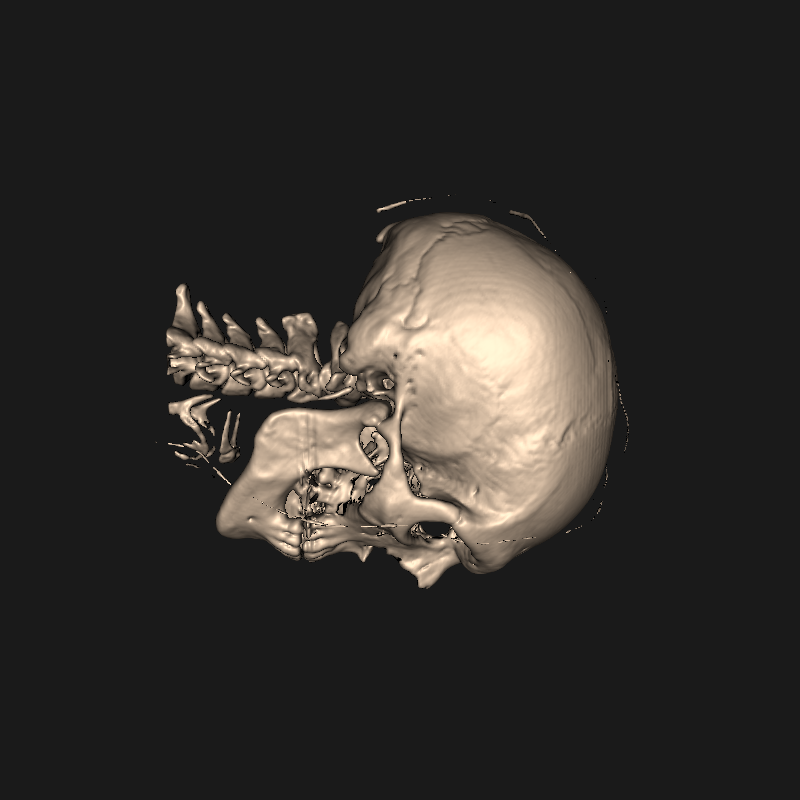

iteration 6: satisfies_goal=False
  isovalue=80.0  azimuth_delta=90  elevation_delta=0  zoom_delta=1.0  confidence=0.85
  reasoning: The current view shows the skull from an inferior/anterior oblique angle, looking up at the base of the skull with the mandible and facial bones prominent. I can see the palate, mandible, and zygomatic arches. For a lateral view with the superior aspect at the top, I need to rotate the camera approximately 90 degrees around the skull to view it from the side. The isovalue of 80.0 appears appropriate as it clearly shows bone structure. No elevation change is needed as the superior aspect already appears to be oriented upward in the volume, I just need to view it from the side rather than from below/front.



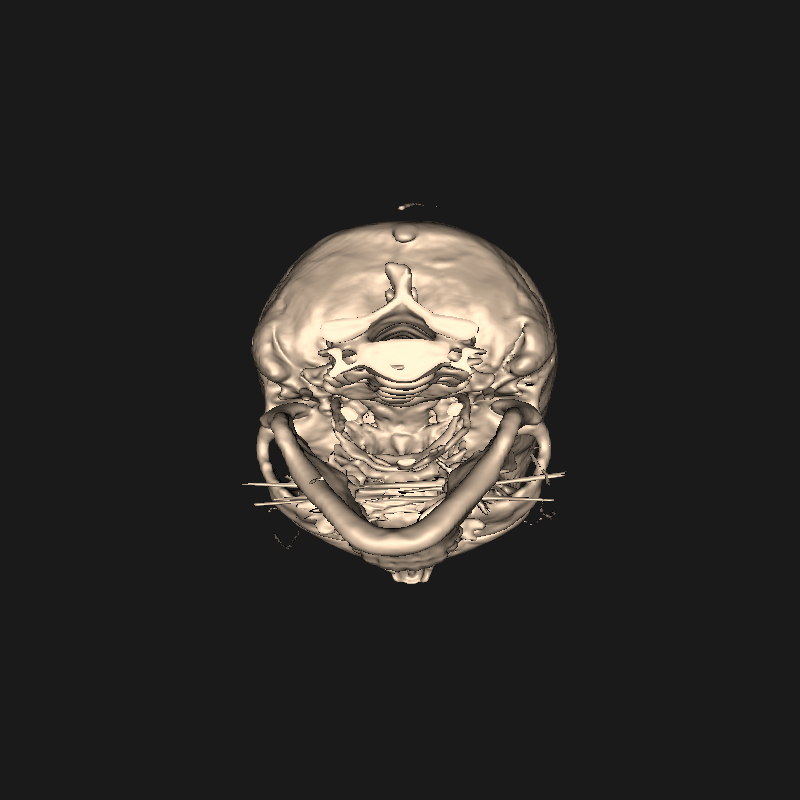

iteration 7: satisfies_goal=False
  isovalue=80.0  azimuth_delta=90  elevation_delta=0  zoom_delta=1.0  confidence=0.85
  reasoning: The current view shows the skull from an oblique anterolateral angle, with the upper teeth and jaw visible from below. I can see the cranium, facial bones, and cervical spine. For a proper lateral view with the superior aspect at the top, I need to rotate the camera 90 degrees to the right (azimuth_delta: 90) to achieve a true lateral (side) profile view. The isovalue of 80.0 appears appropriate as it clearly shows the bony structures of the skull. The elevation seems acceptable as the superior aspect already appears roughly at the top, so no elevation change is needed. The zoom level is adequate.



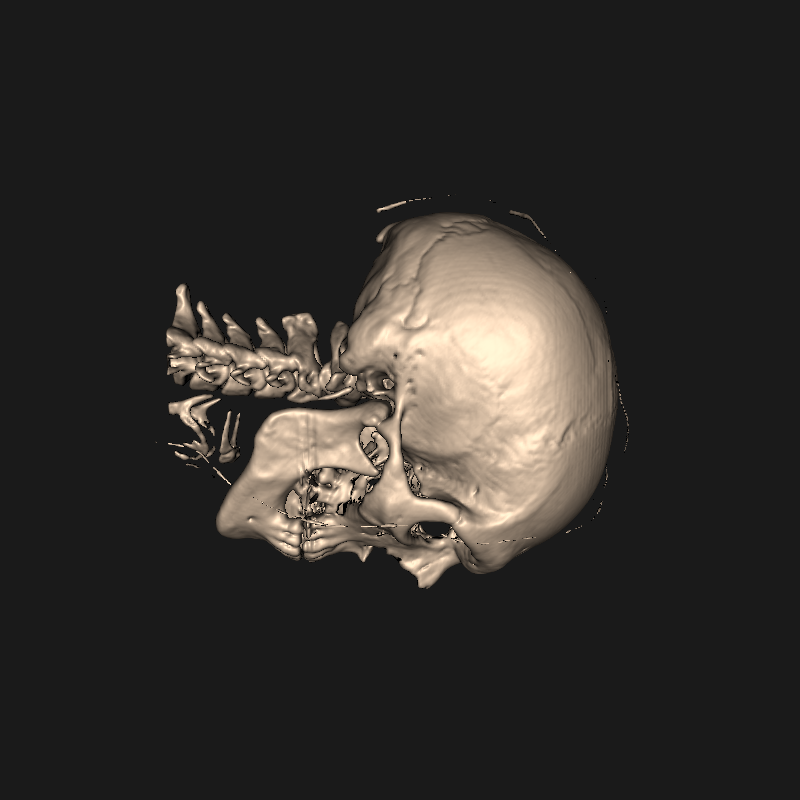

iteration 8: satisfies_goal=False
  isovalue=80.0  azimuth_delta=90  elevation_delta=0  zoom_delta=1.0  confidence=0.9
  reasoning: The current view shows a superior view looking down at the top of the skull (showing the calvarium from above). The goal requires a lateral view with the superior aspect at the top. To achieve a lateral view, I need to rotate the camera around the skull by approximately 90 degrees in azimuth. The isovalue of 80.0 appears appropriate as it shows good bone detail. No elevation change is needed as we want to maintain the same vertical relationship, just view from the side. No zoom change needed as the skull is well-framed.



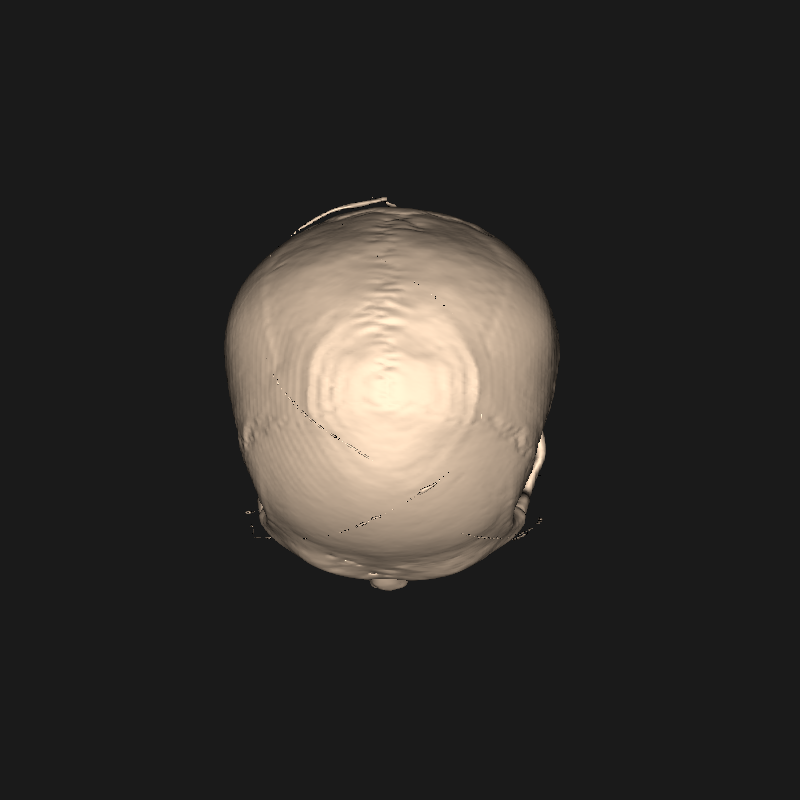

iteration 9: satisfies_goal=False
  isovalue=80.0  azimuth_delta=0  elevation_delta=0  zoom_delta=1.3  confidence=0.75
  reasoning: The current view shows a skull in what appears to be a lateral (side) view with the superior aspect (top of skull) at the top, which matches the goal orientation. However, the skull also includes the cervical spine (neck vertebrae) extending to the right, and the mandible (jaw) is visible. The view is somewhat tilted/oblique. The isovalue of 80.0 appears appropriate for showing bone structure. The main issue is that the skull could be larger in the frame for better visualization. A zoom_delta of 1.3 will bring the camera closer to fill more of the frame with the skull while maintaining the correct lateral orientation.



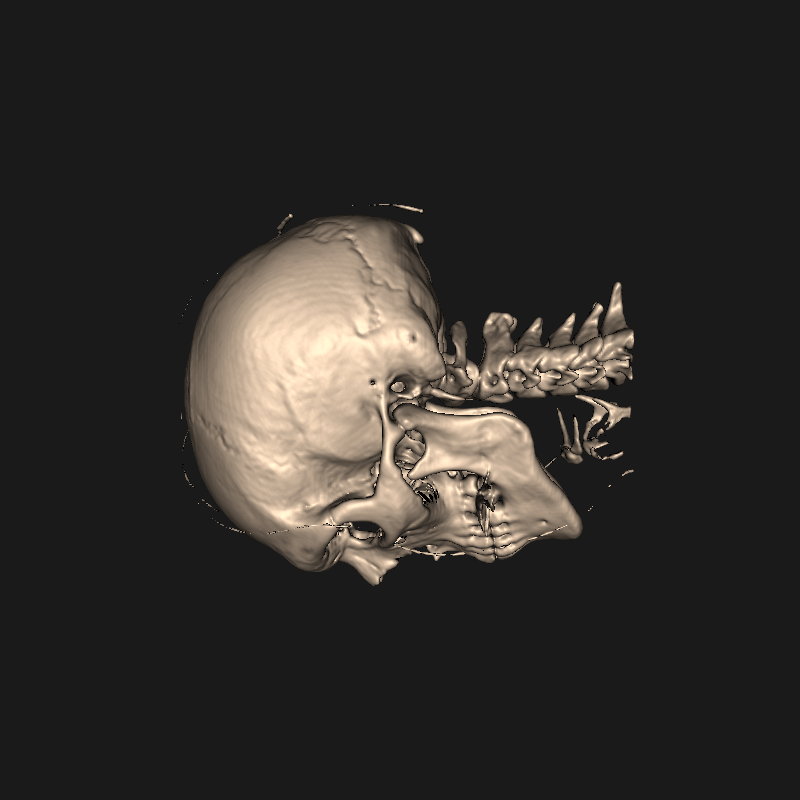

Stopped after 10 iterations without the model reporting satisfaction.

Final isovalue=80.0


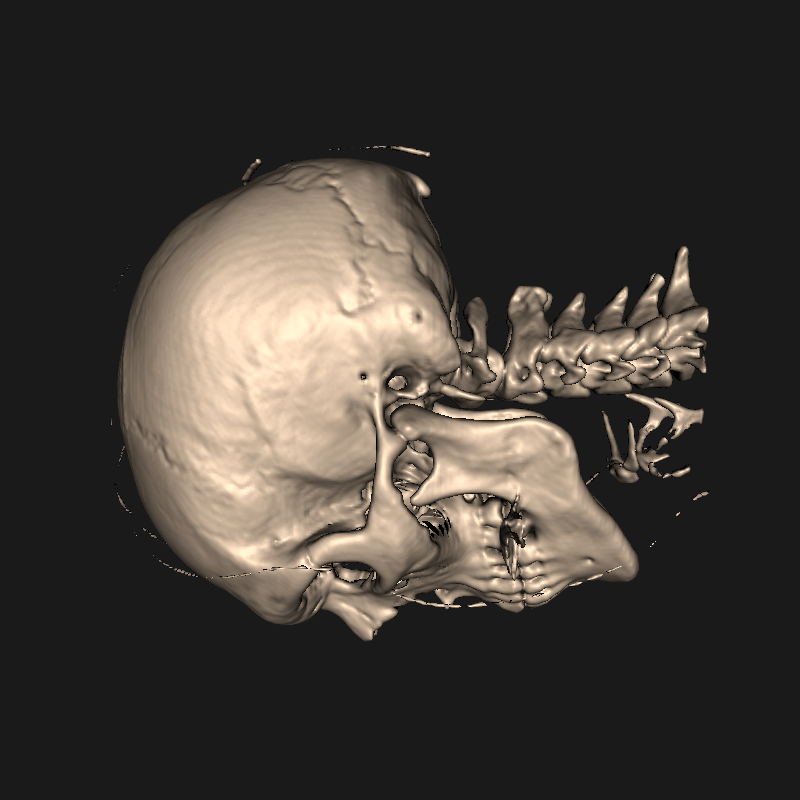

In [8]:
goal = "Show the skull in a lateral view, with the superior aspect at the top."

MAX_ITERATIONS = 10

session.set_isovalue(STARTING_ISOVALUE)
session.reset_camera()

iteration_history = []
for i in range(MAX_ITERATIONS):
    result = ask_direct_step(session, goal)
    parsed = result["parsed"] or {}
    iteration_history.append(result)

    print(f"iteration {i}: satisfies_goal={parsed.get('current_satisfies_goal')}")
    print(f"  isovalue={parsed.get('isovalue')}  azimuth_delta={parsed.get('azimuth_delta')}  "
          f"elevation_delta={parsed.get('elevation_delta')}  zoom_delta={parsed.get('zoom_delta')}  "
          f"confidence={parsed.get('confidence')}")
    print(f"  reasoning: {parsed.get('reasoning')}\n")
    display(Image(filename=result["image_path"]))

    if parsed.get("current_satisfies_goal"):
        print(f"Stopped at iteration {i}: model reports goal satisfied.")
        break

    apply_direct_step(session, parsed)
else:
    print(f"Stopped after {MAX_ITERATIONS} iterations without the model reporting satisfaction.")

final_image = session.render_and_save()
print(f"\nFinal isovalue={session.isovalue}")
display(Image(filename=final_image))

## Run it repeatedly -- same goal, fresh calls

Re-runs the exact same one-shot ask against the SAME starting isovalue AND SAME starting
camera position every round (not continuing from the previous result, unlike the
iterative loop above), to check for non-determinism across repeated identical calls --
see the "Non-determinism / inconsistency across repeated identical calls" finding in
`isovalue_llm_findings_and_next_steps.md`. Now checks non-determinism in the proposed
camera deltas too, not just isovalue.

In [ ]:
ROUNDS = 5

history = []
for i in range(ROUNDS):
    session.set_isovalue(STARTING_ISOVALUE)
    session.reset_camera()
    result = ask_direct_step(session, goal)
    parsed = result["parsed"] or {}
    picked = parsed.get("isovalue")
    azimuth_delta = parsed.get("azimuth_delta")
    elevation_delta = parsed.get("elevation_delta")
    zoom_delta = parsed.get("zoom_delta")
    confidence = parsed.get("confidence")
    reasoning = parsed.get("reasoning")
    history.append(result)
    print(f"round {i}: isovalue={picked}  azimuth_delta={azimuth_delta}  "
          f"elevation_delta={elevation_delta}  zoom_delta={zoom_delta}  confidence={confidence}")
    print(f"  reasoning: {reasoning}\n")

isovalues_picked = [(r["parsed"] or {}).get("isovalue") for r in history]
azimuths_picked = [(r["parsed"] or {}).get("azimuth_delta") for r in history]
elevations_picked = [(r["parsed"] or {}).get("elevation_delta") for r in history]

print("All isovalue picks:", isovalues_picked)
print("Same isovalue every time?", len(set(isovalues_picked)) <= 1)
print("All azimuth_delta picks:", azimuths_picked)
print("Same azimuth_delta every time?", len(set(azimuths_picked)) <= 1)
print("All elevation_delta picks:", elevations_picked)
print("Same elevation_delta every time?", len(set(elevations_picked)) <= 1)

## Compare against the agent pipeline

Same goal, same starting isovalue, run through the real orchestrator (see
`visualization_orchestrator_demo.ipynb` -- blind windows, goal-aware selection, criteria
checking, refinement, verifier) for a direct side-by-side comparison.

In [ ]:
from visualization_orchestrator import VisualizationOrchestrator

orchestrator = VisualizationOrchestrator(
    dataset_path=DATASET_PATH,
    dimensions=DIMENSIONS,
    spacing=SPACING,
    isovalue=STARTING_ISOVALUE,
    output_dir="../output/direct_llm_baseline_agent_comparison",
)
agent_result = orchestrator.run(goal)
print(f"agent success={agent_result.success}")
display(Image(filename=orchestrator.image_path))

## What to look for

Cross-reference against the documented failure modes in
`isovalue_llm_findings_and_next_steps.md` ("What the LLM is bad at"):

- **Goal-conditioned hallucination** -- does the `reasoning` text describe bone/anatomical
  detail that isn't actually visible in the image?
- **Non-determinism** -- do the 5 repeated rounds above pick different isovalues, and
  different camera deltas, for the identical starting image and goal?
- **Overconfident self-scoring** -- is `confidence` high even when the picked isovalue
  and/or camera position visibly fails the goal?
- **Camera thrashing / non-convergence** -- in the iterative loop, does the camera
  oscillate (e.g. alternating azimuth sign) instead of settling, since each round only
  ever sees the current image with no memory of prior attempts or their outcomes?

None of this is present by construction in the agent pipeline (Stage 1 never sees the
goal, Stage 2 never sees the image, selection is grounded in stored text observations and
explicit success criteria, not a single opaque one-shot judgment, and camera moves come
from a small named action vocabulary with candidate-render grounding rather than
free-form continuous deltas).